# 🌍 Matplotlib Visualization Tutorial
### Global Population & Economy Edition

This notebook covers **7 chart types** using `matplotlib`, `numpy`, and `pandas`  
applied to real-world **population and economic data**.

| # | Chart Type | Dataset |
|---|-----------|---------|
| 1 | Line Graph | Manual x/y — Population growth model |
| 2 | Bar Graph | Regional average GDP per capita |
| 3 | Real-World Line Graph | `gdp_trends.csv` — 8 countries, 1995–2023 |
| 4 | Histogram | `world_population.csv` — Life expectancy distribution |
| 5 | Pie Chart (Basic) | `world_population.csv` — Countries by continent |
| 6 | Pie Chart (Advanced) | `world_population.csv` — Population by income group |
| 7 | Box Plot | `world_population.csv` — HDI scores by continent |

> **Required files** (place in the same folder as this notebook):
> - `gdp_trends.csv`
> - `world_population.csv`


## 📦 Imports
Run this cell first — every chart below depends on these libraries.

In [13]:
%pip install matplotlib numpy pandas

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 6.1 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 6.6 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.2 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 6.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 6.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.3 MB 7.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------- ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import matplotlib.pyplot as plt   # core plotting library
import numpy as np                 # numerical arrays and math
import pandas as pd                # loading and filtering CSV data


---
## 1️⃣ Line Graph — Population Growth Model

**Concepts covered:**
- `plt.figure(figsize, dpi)` — resize the canvas
- `plt.plot()` with shorthand notation (`'r^--'`, `'g^--'`, `'b'`)
- `np.arange(start, stop, step)` — evenly-spaced arrays
- Slicing arrays with `[:n]` and `[n:]` to plot partial ranges
- `plt.xticks / yticks` — manually set tick labels
- `plt.savefig()` — export chart before calling `plt.show()`

**What we're plotting:**  
Two simplified population growth curves — linear vs exponential —  
to show how different growth models diverge over time.


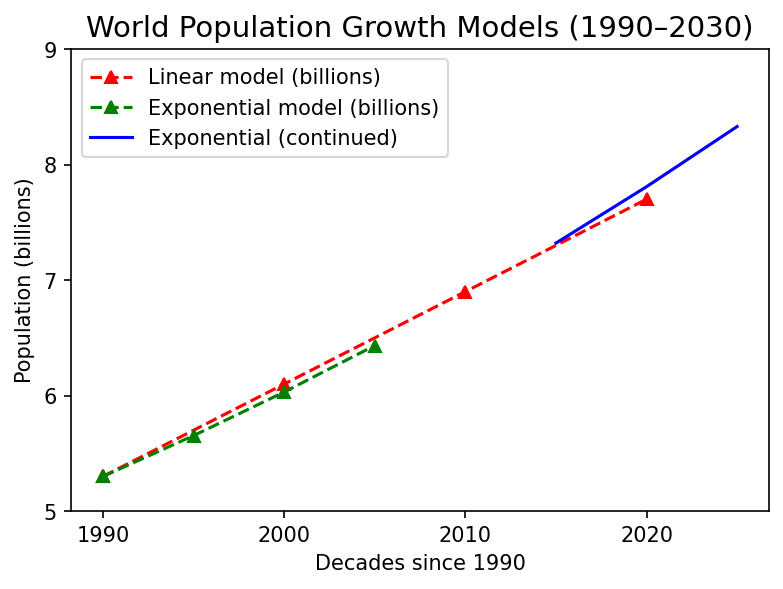

In [15]:
# ── Figure size & resolution ─────────────────────────────────────────────────
# figsize=(width, height) in inches | dpi = dots per inch (higher = sharper)
plt.figure(figsize=(6, 4), dpi=150)

# ── Line 1: Linear growth (steady fixed increase each decade) ─────────────────
decades  = [0, 1, 2, 3]                  # decades since 1990
pop_lin  = [5.3, 6.1, 6.9, 7.7]         # billions (approx. linear)

# Shorthand: 'r^--' → red colour, triangle marker, dashed line
plt.plot(decades, pop_lin, 'r^--', label='Linear model (billions)')

# ── Line 2: Exponential growth using NumPy ───────────────────────────────────
# np.arange(start, stop, step) creates [0.0, 0.5, 1.0, ... 3.5]
t = np.arange(0, 4, 0.5)

# Plot only the FIRST 4 values (indices 0-3) as a green dashed line
plt.plot(t[:4], 5.3 * (1.013 ** (t[:4] * 10)), 'g^--', label='Exponential model (billions)')

# Plot from index 5 ONWARD as a solid blue line — shows divergence after 2010
plt.plot(t[5:], 5.3 * (1.013 ** (t[5:] * 10)), 'b', label='Exponential (continued)')

# ── Labels & ticks ────────────────────────────────────────────────────────────
plt.title("World Population Growth Models (1990–2030)",
          fontdict={'fontname': 'DejaVu Sans', 'fontsize': 14})
plt.xlabel("Decades since 1990")
plt.ylabel("Population (billions)")
plt.xticks([0, 1, 2, 3],
           labels=['1990', '2000', '2010', '2020'])  # readable year labels
plt.yticks([5, 6, 7, 8, 9])
plt.legend()

# ── Save & show ───────────────────────────────────────────────────────────────
# IMPORTANT: savefig() must come BEFORE show() — show() clears the figure
plt.savefig("population_growth_model.jpeg", dpi=150)
plt.show()


---
## 2️⃣ Bar Graph — Average GDP per Capita by Region

**Concepts covered:**
- `plt.bar(labels, values)` — basic vertical bar chart
- `bar.set_hatch()` — add texture patterns to bars
- Iterating over the bar container to customise each bar individually

**What we're plotting:**  
Approximate average GDP per capita (USD) for 6 world regions —  
a quick visual comparison of economic output per person.


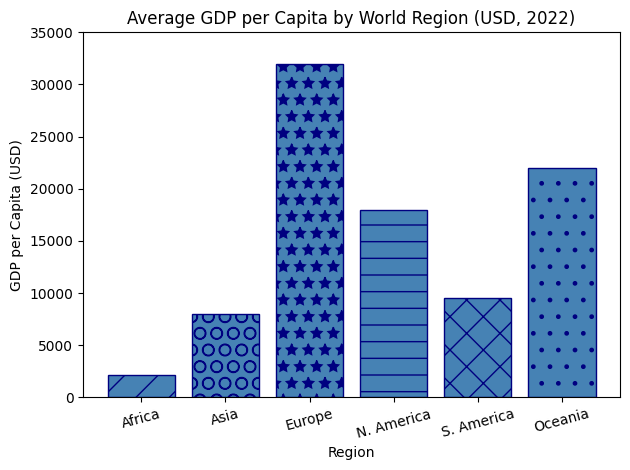

In [16]:
# ── Data: approximate 2022 GDP per capita by world region ────────────────────
regions = ['Africa', 'Asia', 'Europe', 'N. America', 'S. America', 'Oceania']
avg_gdp = [2100,      8000,   32000,    18000,         9500,         22000]

# plt.bar() returns a BarContainer — store it to style individual bars
bar_container = plt.bar(regions, avg_gdp, color='steelblue', edgecolor='navy')

# ── Hatch patterns ────────────────────────────────────────────────────────────
# Available patterns: '/' '\' '|' '-' '+' 'x' 'o' 'O' '.' '*'
# Each pattern is assigned to one bar using pop(0) to remove as we go
patterns = ['/', 'O', '*', '-', 'x', '.']

for bar in bar_container:
    bar.set_hatch(patterns.pop(0))   # removes first pattern and applies it

# ── Labels & formatting ───────────────────────────────────────────────────────
plt.title("Average GDP per Capita by World Region (USD, 2022)")
plt.xlabel("Region")
plt.ylabel("GDP per Capita (USD)")
plt.xticks(rotation=15)                          # angle labels to avoid overlap
plt.yticks([0, 5000, 10000, 15000, 20000, 25000, 30000, 35000])
plt.tight_layout()                               # prevents label clipping
plt.show()


---
## 3️⃣ Real-World Line Graph — GDP per Capita Over Time

**Concepts covered:**
- `pd.read_csv()` — load a CSV into a DataFrame
- Looping over `df.columns` to plot all series automatically
- `df['Year'][::3]` — slice with step to thin out x-axis tick labels
- `plt.savefig()` — note: correct spelling is `savefig`, **not** `save_fig`

> ⚠️ Requires `gdp_trends.csv` in the same folder.


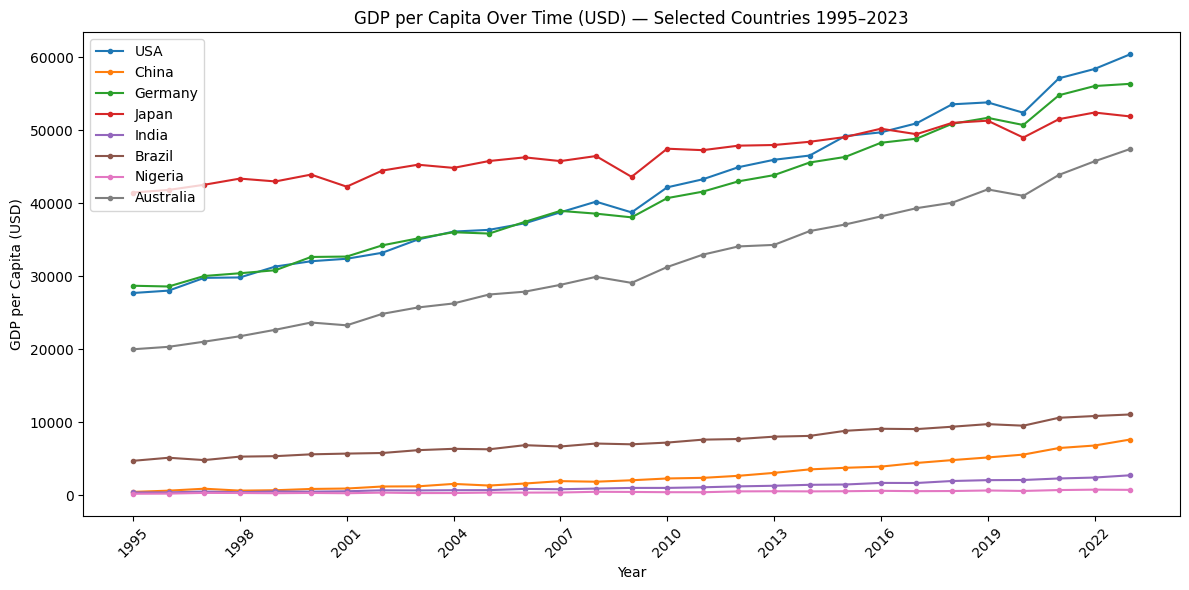

In [17]:
# ── Load data ─────────────────────────────────────────────────────────────────
gdp = pd.read_csv('gdp_trends.csv')

plt.figure(figsize=(12, 6))
plt.title('GDP per Capita Over Time (USD) — Selected Countries 1995–2023')

# ── Plot every country column automatically ───────────────────────────────────
# gdp.columns contains 'Year' plus one column per country.
# We skip 'Year' because that's the x-axis, not a data series.
for country in gdp.columns:
    if country != 'Year':
        plt.plot(gdp['Year'], gdp[country], marker='.', label=country)

# ── Axis labels & ticks ───────────────────────────────────────────────────────
# gdp['Year'][::3] selects every 3rd year to avoid crowded tick labels
plt.xticks(gdp['Year'][::3], rotation=45)
plt.xlabel("Year")
plt.ylabel("GDP per Capita (USD)")
plt.legend(loc='upper left')

# ── Save & show ───────────────────────────────────────────────────────────────
# IMPORTANT: savefig() not save_fig() — common mistake!
plt.savefig("gdp_trends.jpeg", dpi=150)
plt.tight_layout()
plt.show()


---
## 4️⃣ Histogram — Life Expectancy Distribution

**Concepts covered:**
- `plt.hist(data, bins=[...])` — frequency distribution chart
- Custom `bins` list — control the exact bucket boundaries
- `plt.xticks(bins)` — align tick labels to bin edges

**What we're plotting:**  
How life expectancy is distributed across 88 countries —  
which range is most common, and where the outliers sit.

> ⚠️ Requires `world_population.csv` in the same folder.


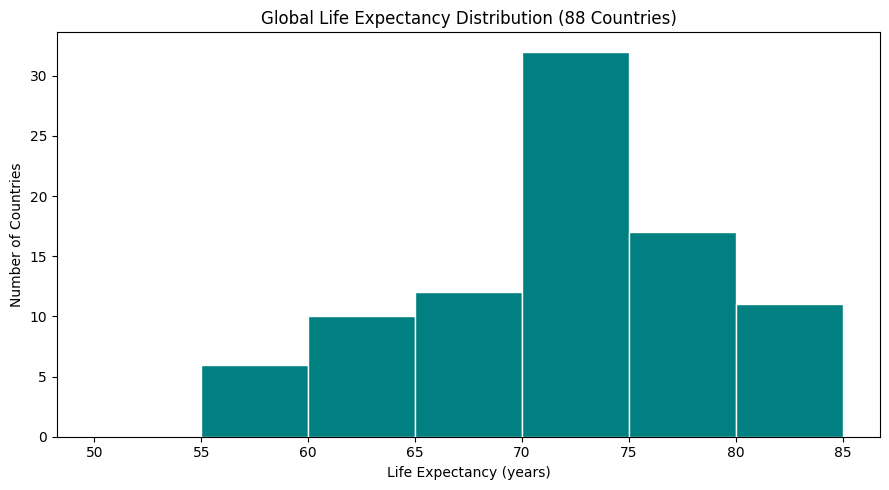

In [19]:
# ── Load data ─────────────────────────────────────────────────────────────────
wp = pd.read_csv('world_population.csv')

# ── Define bin edges ──────────────────────────────────────────────────────────
# Each consecutive pair defines one bar:
#   50-55, 55-60, 60-65, 65-70, 70-75, 75-80, 80-85
bins_le = [50, 55, 60, 65, 70, 75, 80, 85]

# ── Draw histogram ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.hist(wp['LifeExpectancy'], bins=bins_le, color='teal', edgecolor='white')

# ── Labels ────────────────────────────────────────────────────────────────────
plt.xticks(bins_le)              # tick mark at every bin boundary
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Number of Countries")
plt.title("Global Life Expectancy Distribution (88 Countries)")
plt.tight_layout()
plt.show()


---
## 5️⃣ Pie Chart — Countries by Continent (Basic)

**Concepts covered:**
- Filtering with `.loc[]` and counting with `.count()[0]`
- `plt.pie(values, autopct='%.2f %%')` — percentages with 2 decimal places
- `%%` — escape sequence for a literal `%` sign inside a format string

> ⚠️ Requires `world_population.csv` in the same folder.


C:\Users\David\AppData\Local\Temp\ipykernel_7356\2506993250.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  africa    = wp.loc[wp['Continent'] == 'Africa'].count()[0]
C:\Users\David\AppData\Local\Temp\ipykernel_7356\2506993250.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  asia      = wp.loc[wp['Continent'] == 'Asia'].count()[0]
C:\Users\David\AppData\Local\Temp\ipykernel_7356\2506993250.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `s

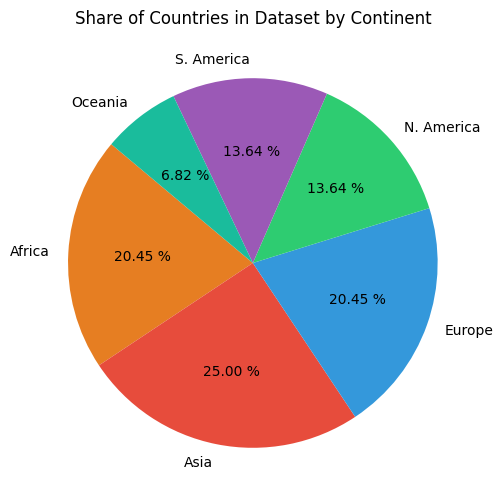

In [20]:
# ── Load data ─────────────────────────────────────────────────────────────────
wp = pd.read_csv('world_population.csv')

# ── Count countries per continent ─────────────────────────────────────────────
# .loc[condition] filters rows; .count()[0] returns the count as an integer
africa    = wp.loc[wp['Continent'] == 'Africa'].count()[0]
asia      = wp.loc[wp['Continent'] == 'Asia'].count()[0]
europe    = wp.loc[wp['Continent'] == 'Europe'].count()[0]
n_america = wp.loc[wp['Continent'] == 'North America'].count()[0]
s_america = wp.loc[wp['Continent'] == 'South America'].count()[0]
oceania   = wp.loc[wp['Continent'] == 'Oceania'].count()[0]

# ── Chart settings ────────────────────────────────────────────────────────────
counts     = [africa, asia, europe, n_america, s_america, oceania]
labelsx    = ['Africa','Asia','Europe','N. America','S. America','Oceania']
colorsx    = ['#e67e22','#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']

# autopct '%.2f %%':  %.2f = 2 decimal float  |  %% = literal %
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=labelsx, colors=colorsx, autopct='%.2f %%', startangle=140)
plt.title("Share of Countries in Dataset by Continent")

# ── Save & show ───────────────────────────────────────────────────────────────
plt.savefig("countries_by_continent.jpeg", dpi=150)
plt.show()


---
## 6️⃣ Pie Chart — Population by Income Group (Advanced)

**Concepts covered:**
- `plt.style.use('ggplot')` — apply a built-in style theme
- List comprehension to clean mixed string/numeric data:  
  `[float(str(x).replace('M','')) if 'M' in str(x) else x ...]`
- Filtering with compound conditions: `(df.col >= a) & (df.col < b)`
- `explode` — pull slices outward from the centre
- `pctdistance` — push percentage labels inward or outward

> ⚠️ Requires `world_population.csv` in the same folder.  
> Note: ~30% of `Population(M)` values are stored as strings like `"45.3M"` —  
> this cell shows you how to clean that before analysis.


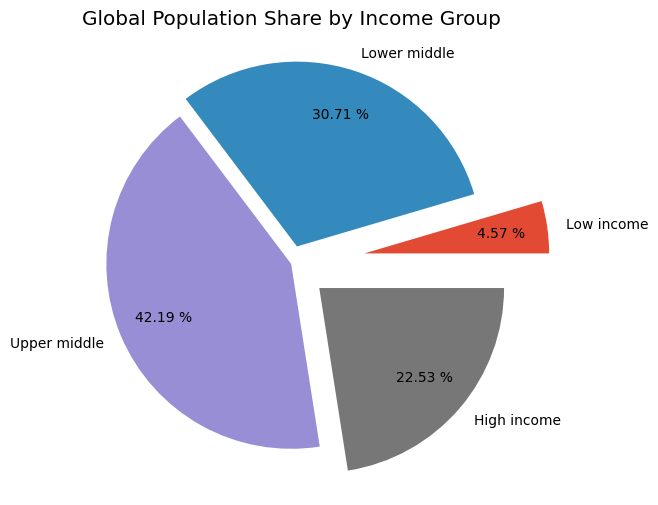

In [21]:
# ── Load data ─────────────────────────────────────────────────────────────────
wp = pd.read_csv('world_population.csv')

plt.figure(figsize=(9, 6), dpi=100)
plt.style.use('ggplot')   # apply the ggplot colour/grid style

# ── Clean the Population(M) column ───────────────────────────────────────────
# ~30% of rows store population as a string like "45.3M"
# List comprehension: strip 'M' and convert to float only when it's a string
wp['Population(M)'] = [
    float(str(x).replace('M', '')) if 'M' in str(x) else float(x)
    for x in wp['Population(M)']
]

# ── Sum population per income group ───────────────────────────────────────────
# loc[condition] filters rows; ['Population(M)'].sum() totals that column
low    = wp.loc[wp['IncomeGroup'] == 'Low income',            'Population(M)'].sum()
lo_mid = wp.loc[wp['IncomeGroup'] == 'Lower middle income',   'Population(M)'].sum()
up_mid = wp.loc[wp['IncomeGroup'] == 'Upper middle income',   'Population(M)'].sum()
high   = wp.loc[wp['IncomeGroup'] == 'High income',           'Population(M)'].sum()

populations = [low, lo_mid, up_mid, high]
labels      = ['Low income', 'Lower middle', 'Upper middle', 'High income']

# ── Explode ───────────────────────────────────────────────────────────────────
# Each value pulls that slice outward by that fraction of the radius
explode = (0.4, 0.1, 0, 0.2)

plt.title('Global Population Share by Income Group')

# pctdistance=0.75 → move percentage text to 75% from centre to edge
plt.pie(populations, labels=labels, explode=explode,
        pctdistance=0.75, autopct='%.2f %%')
plt.show()


---
## 7️⃣ Box Plot — HDI Score by Continent

**Concepts covered:**
- `plt.boxplot()` — shows median, IQR (Q1–Q3), whiskers, and outliers
- `patch_artist=True` — enables fill colour on boxes
- `medianprops` — customise the median line appearance
- Iterating over `boxes['boxes']` to set per-box border and fill colour

**What we're plotting:**  
Human Development Index (HDI) scores grouped by continent —  
great for spotting which regions have the widest spread of development levels.

> ⚠️ Requires `world_population.csv` in the same folder.


C:\Users\David\AppData\Local\Temp\ipykernel_7356\655275290.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = plt.boxplot(


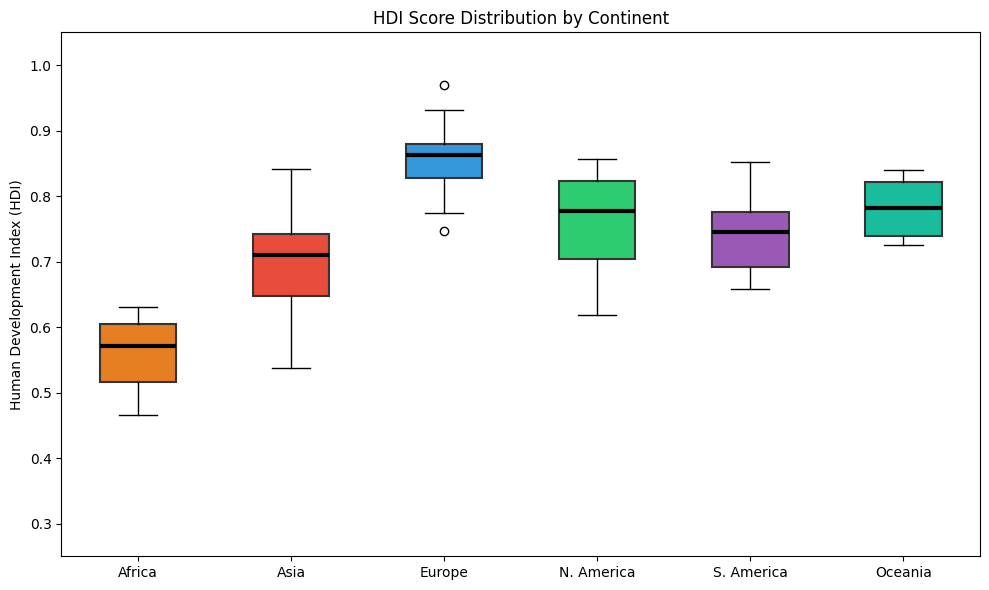

In [22]:
# ── Load data ─────────────────────────────────────────────────────────────────
wp = pd.read_csv('world_population.csv')

plt.figure(figsize=(10, 6))
plt.style.use('default')    # reset to default style

# ── Extract HDI Series for each continent ─────────────────────────────────────
# .loc[condition]['column'] filters rows then selects one column as a Series
africa    = wp.loc[wp['Continent'] == 'Africa']['HDI']
asia      = wp.loc[wp['Continent'] == 'Asia']['HDI']
europe    = wp.loc[wp['Continent'] == 'Europe']['HDI']
n_america = wp.loc[wp['Continent'] == 'North America']['HDI']
s_america = wp.loc[wp['Continent'] == 'South America']['HDI']
oceania   = wp.loc[wp['Continent'] == 'Oceania']['HDI']

labelsx = ['Africa', 'Asia', 'Europe', 'N. America', 'S. America', 'Oceania']

# ── Draw box plot ─────────────────────────────────────────────────────────────
# patch_artist=True  → required to set facecolor on each box
# medianprops        → dict to style the median line
boxes = plt.boxplot(
    [africa, asia, europe, n_america, s_america, oceania],
    labels=labelsx,
    patch_artist=True,
    medianprops={'linewidth': 3, 'color': 'black'}
)

# ── Style each box with a unique fill colour ──────────────────────────────────
box_colors = ['#e67e22','#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
for box, color in zip(boxes['boxes'], box_colors):
    box.set(color='#333333', linewidth=1.5)   # border colour
    box.set(facecolor=color)                  # fill colour

# ── Labels ────────────────────────────────────────────────────────────────────
plt.ylabel("Human Development Index (HDI)")
plt.title("HDI Score Distribution by Continent")
plt.ylim(0.25, 1.05)
plt.tight_layout()
plt.show()


---
## ✅ Summary — Quick Reference

| Chart | Function | Best used for |
|-------|----------|---------------|
| Line | `plt.plot()` | Trends over time |
| Bar | `plt.bar()` | Comparing categories |
| Histogram | `plt.hist()` | Frequency distributions |
| Pie (Basic) | `plt.pie()` | Part-to-whole by count |
| Pie (Advanced) | `plt.pie()` | Part-to-whole by summed value |
| Box Plot | `plt.boxplot()` | Spread & outliers per group |

### Common `plt.plot()` shorthand codes
| Code | Colour / Marker / Line |
|------|------------------------|
| `r` `g` `b` `y` `k` | red / green / blue / yellow / black |
| `.` `o` `^` `s` `*` | point / circle / triangle / square / star |
| `-` `--` `-.` `:` | solid / dashed / dash-dot / dotted |

Combine: `'r^--'` = red triangle markers with dashed line

### Common mistakes
| ✗ Wrong | ✓ Correct |
|---------|----------|
| `plt.save_fig()` | `plt.savefig()` |
| `savefig()` after `show()` | `savefig()` **before** `show()` |
| `df['col']>a & df['col']<b` | `(df['col']>a) & (df['col']<b)` |
| `df.columns()` | `df.columns` (no parentheses) |
